<a href="https://colab.research.google.com/github/abigail-vmunoz/Proyecto-final_Ciencia-de-Datos-UNAM-/blob/main/Proyecto_final_Ciencia_de_Datos_UNAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto final**

### Diplomado en Ciencia de Datos
### Universidad Nacional Autónoma de México (UNAM)
### División de Educación Continua e Innovación ENES León


**Título:** Análisis exploratorio de la proporción motocicletas por automóvil en la zona metropolitana de León y su relación con variables económicas de ingresos laborales y empleo informal

In [46]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import seaborn as sns
from scipy import stats

In [47]:
# Datos
df = pd.read_csv("datos_diplomado.csv")
df.head()

,anio,motos,autos,proporcion,ingreso,tasa
0,2005,9513,182849,0.052027,10641.50,29.754762
1,2006,13022,206126,0.063175,10853.52,29.766663
2,2007,16463,224548,0.073316,11104.32,27.477682
3,2008,20047,246873,0.081204,10470.82,27.434147
4,2009,21926,258563,0.084799,9757.53,27.419476


In [48]:
# Estilo base
plt.style.use("seaborn-v0_8-darkgrid")
# Estilo de gráficas
colores_azul = {
    'Azul1': '#007A99',
    'Azul2': '#00AACC',
    'Azul3': '#4DBBD5',
    'Azul4': '#52C4CC',
    'Azul5': '#0F6B99',
    'Azul6': '#4A6990'
    }
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 10,
    "axes.labelsize": 12,
    "font.family": "DejaVu Serif",
    "lines.linewidth": 2
})

# **1. Gráficas generales de las variables**

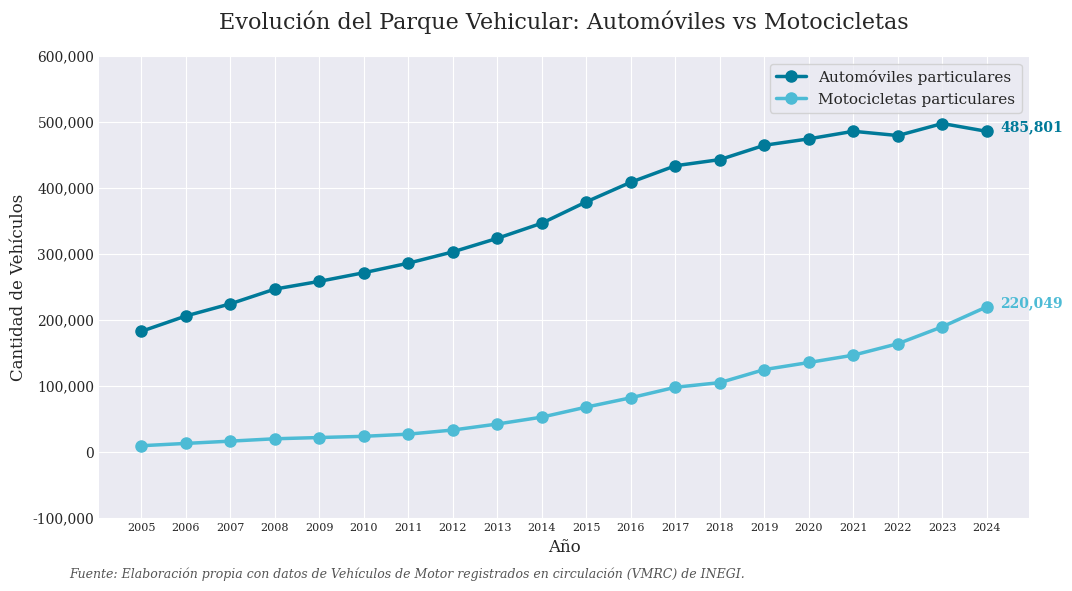

In [49]:
#Grafica de motocicletas y autos
plt.figure(figsize=(12, 6))

#Automóviles
plt.plot(df['anio'], df['autos'], 'o-',
         label='Automóviles particulares',
         color=colores_azul['Azul1'],
         markersize=8,
         linewidth=2.5)
# Motocicletas
plt.plot(df['anio'], df['motos'], 'o-',
         label='Motocicletas particulares',
         color=colores_azul['Azul3'],
         markersize=8,
         linewidth=2.5)

plt.text(df['anio'].iloc[-1] + 0.3, df['autos'].iloc[-1], f"{df['autos'].iloc[-1]:,}",
         color=colores_azul['Azul1'], fontweight='bold')

plt.text(df['anio'].iloc[-1] + 0.3, df['motos'].iloc[-1], f"{df['motos'].iloc[-1]:,}",
         color=colores_azul['Azul3'], fontweight='bold')


ticks_loc = plt.gca().get_yticks()
plt.gca().set_yticks(ticks_loc)
plt.gca().set_yticklabels(['{:,.0f}'.format(x) for x in ticks_loc])

plt.title("Evolución del Parque Vehicular: Automóviles vs Motocicletas", pad=20, fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Cantidad de Vehículos", fontsize=12)
plt.legend(frameon=True, fontsize=11)
plt.xticks(df['anio'].unique(), fontsize=8)


plt.figtext(0.1, 0.01, "Fuente: Elaboración propia con datos de Vehículos de Motor registrados en circulación (VMRC) de INEGI.",
            fontsize=9, fontstyle='italic', color='#555555')
plt.show()


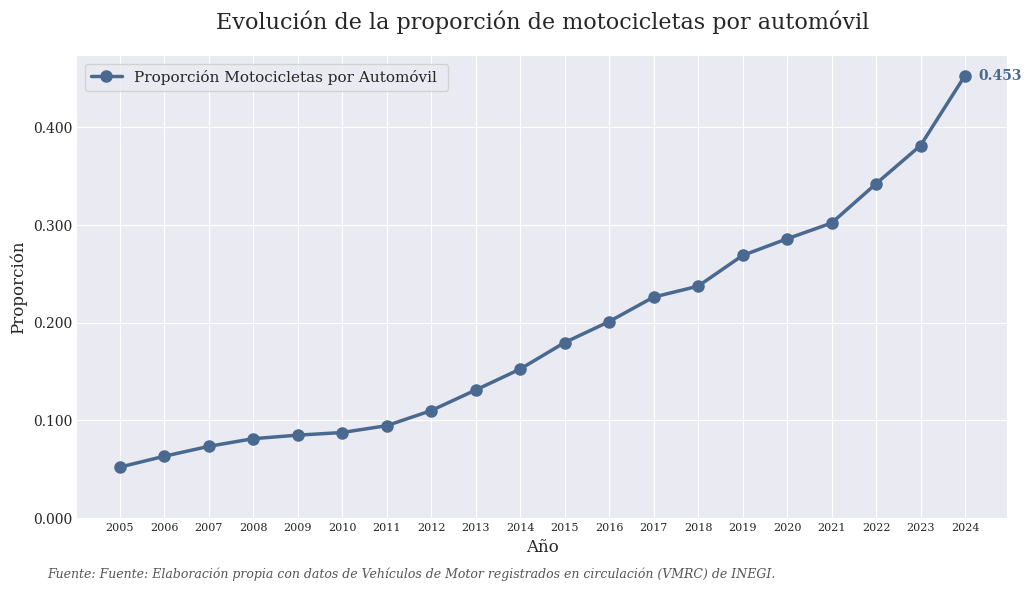

In [50]:
#Gráfica de proporción Motocicletas por Automóvil
plt.figure(figsize=(12, 6))

#Proporción Motocicletas por Automóvil
plt.plot(df['anio'], df['proporcion'], 'o-',
         label='Proporción Motocicletas por Automóvil ',
         color=colores_azul['Azul6'],
         markersize=8,
         linewidth=2.5)

plt.text(df['anio'].iloc[-1] + 0.3, df['proporcion'].iloc[-1],
         f"{df['proporcion'].iloc[-1]:,.3f}", color=colores_azul['Azul6'], fontweight='bold', va='center')

plt.title("Evolución de la proporción de motocicletas por automóvil", pad=20, fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Proporción", fontsize=12)
plt.ylim(0)
plt.legend(frameon=True, fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x):,.3f}'))
plt.xticks(df['anio'].unique(), fontsize=8)


plt.figtext(0.1, 0.01, "Fuente: Fuente: Elaboración propia con datos de Vehículos de Motor registrados en circulación (VMRC) de INEGI.",
            fontsize=9, fontstyle='italic', color='#555555')
plt.show()

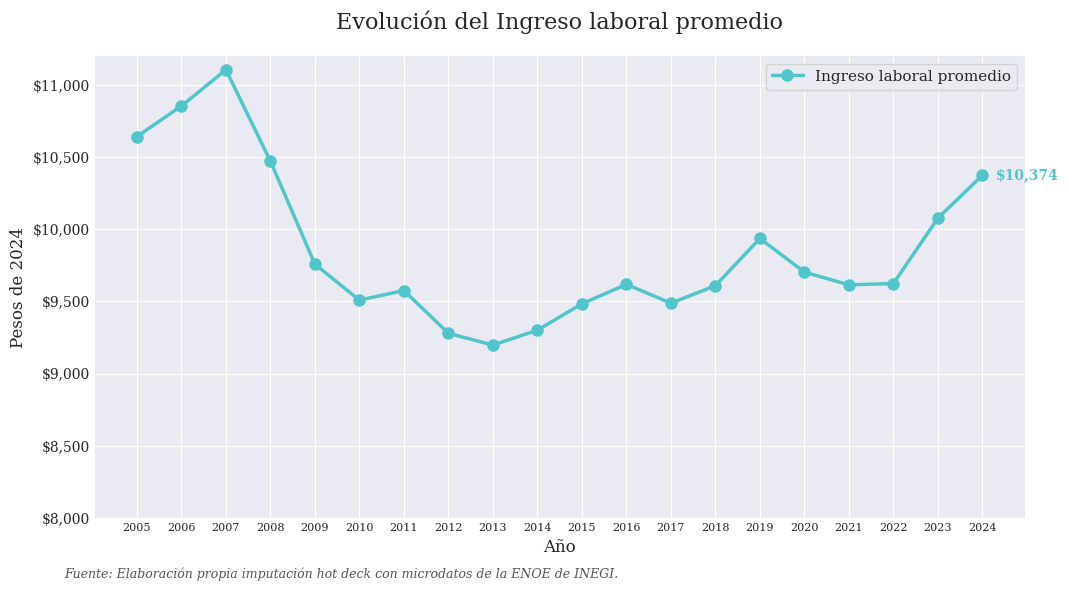

In [51]:
#Gráfica de ingresos laborales promedio
plt.figure(figsize=(12, 6))

#Ingresos
plt.plot(df['anio'], df['ingreso'], 'o-',
         label='Ingreso laboral promedio',
         color=colores_azul['Azul4'],
         markersize=8,
         linewidth=2.5)

plt.text(df['anio'].iloc[-1] + 0.3, df['ingreso'].iloc[-1],
         f"${df['ingreso'].iloc[-1]:,.0f}", color=colores_azul['Azul4'], fontweight='bold', va='center')

plt.title("Evolución del Ingreso laboral promedio", pad=20, fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Pesos de 2024", fontsize=12)
plt.ylim(8000)
plt.legend(frameon=True, fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${int(x):,}'))
plt.xticks(df['anio'].unique(), fontsize=8)


plt.figtext(0.1, 0.01, "Fuente: Elaboración propia imputación hot deck con microdatos de la ENOE de INEGI.",
            fontsize=9, fontstyle='italic', color='#555555')
plt.show()

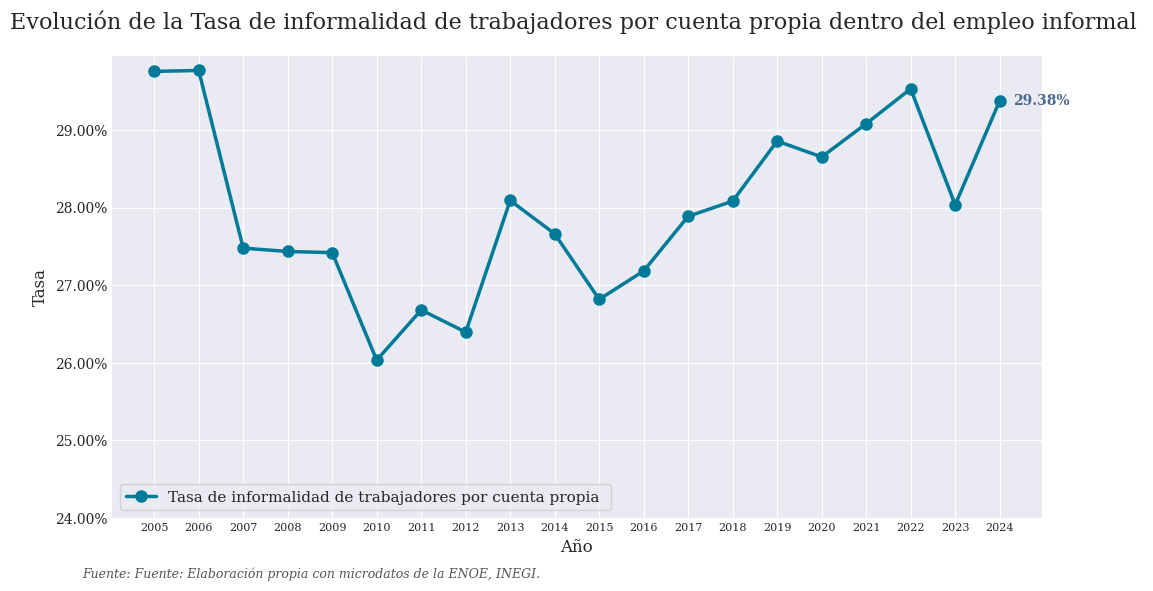

In [52]:
#Gráfica de la tasa de informalidad de trabajadores por cuenta propia
plt.figure(figsize=(12, 6))

#Tasa de informalidad de trabajadores por cuenta propia
plt.plot(df['anio'], df['tasa'], 'o-',
         label='Tasa de informalidad de trabajadores por cuenta propia ',
         color=colores_azul['Azul1'],
         markersize=8,
         linewidth=2.5)

plt.text(df['anio'].iloc[-1] + 0.3, df['tasa'].iloc[-1],
         f'{df['tasa'].iloc[-1]:,.2f}%', color=colores_azul['Azul6'], fontweight='bold', va='center')

plt.title("Evolución de la Tasa de informalidad de trabajadores por cuenta propia dentro del empleo informal ", pad=20, fontsize=16)
plt.xlabel("Año", fontsize=12)
plt.ylabel("Tasa", fontsize=12)
plt.ylim(24)
plt.legend(frameon=True, fontsize=11)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{float(x):,.2f}%'))
plt.xticks(df['anio'].unique(), fontsize=8)

plt.figtext(0.1, 0.01, "Fuente: Fuente: Elaboración propia con microdatos de la ENOE, INEGI.",
            fontsize=9, fontstyle='italic', color='#555555')
plt.show()

# **2. Análisis CUSUM (Suma acumulada)**

In [53]:
#Análisis CUSUM para proporción motocicletas por automóviles
def modelo_cusum_propor(anio, proporcion):
    # 1. Preparación de datos
    X = np.column_stack([np.ones(len(anio)), anio])
    y = np.array(proporcion)
    n, k = X.shape

    X_init = X[:k]
    y_init = y[:k]
    xtx_inv = np.linalg.inv(X_init.T @ X_init)
    beta_t = xtx_inv @ (X_init.T @ y_init)

    w = []
    for t in range(k, n):
        x_actual = X[t]
        prediccion = x_actual @ beta_t
        error = y[t] - prediccion

        # Factor de escala f_t
        f_t = 1 + x_actual @ xtx_inv @ x_actual.T
        w.append(error / np.sqrt(f_t))

        # Recursiva de la inversa (Sherman–Morrison)
        x_vec = x_actual.reshape(-1, 1)
        xtx_inv = xtx_inv - (xtx_inv @ x_vec @ x_vec.T @ xtx_inv) / (1 + x_vec.T @ xtx_inv @ x_vec)

        # Beta
        beta_t = xtx_inv @ (X[:t+1].T @ y[:t+1])

    w = np.array(w)

    # Estimación de sigma
    beta_full = np.linalg.inv(X.T @ X) @ (X.T @ y)
    residuos_full = y - X @ beta_full
    sigma = np.sqrt(np.sum(residuos_full**2) / (n - k))

    # CUSUM con normalización individual
    cusum_valores = np.cumsum(w / sigma)

    return cusum_valores


anio_input = df['anio'].values
propor_input = df['proporcion'].values

serie_cusum_propor = modelo_cusum_propor(anio_input, propor_input)

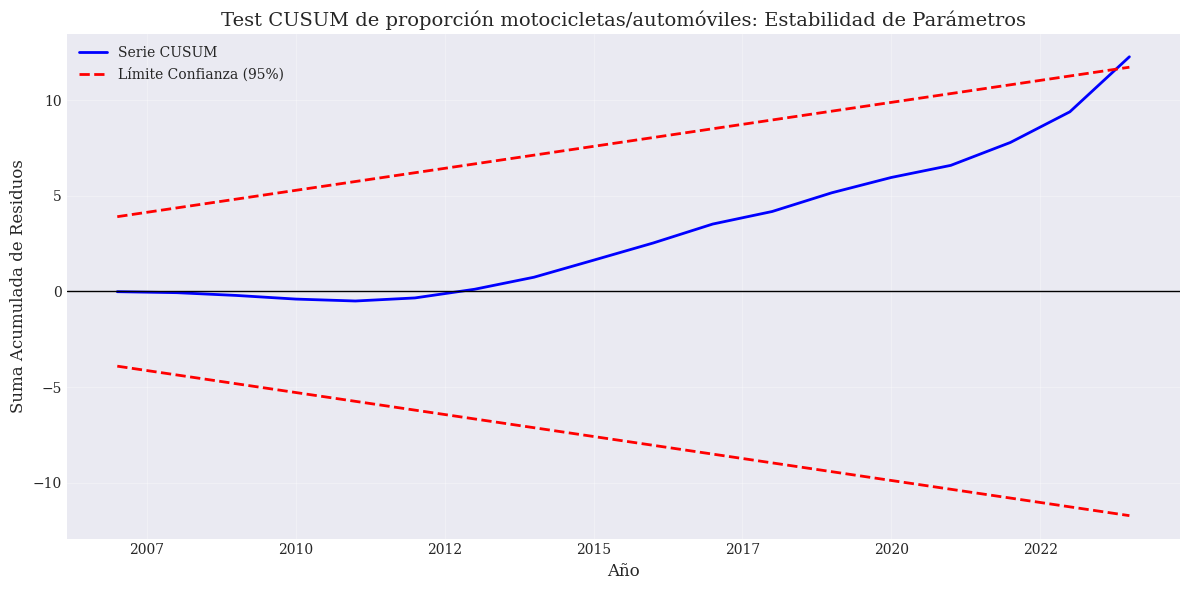

In [54]:
def graficar_cusum_propor(anio, cusum_valores, alpha=0.05):
    m = len(cusum_valores)

    # Valor crítico
    a = 0.948 if alpha == 0.05 else 1.143

    # Construcción de las bandas según Brown, Durbin & Evans
    # La fórmula estándar es: a * sqrt(T-k) + 2 * a * (t-k) / sqrt(T-k)
    # t_vals va de 0 a m-1
    t_vals = np.arange(m)
    sqrt_m = np.sqrt(m - 1)

    banda = a * sqrt_m + (2* a * t_vals / sqrt_m)

    plt.figure(figsize=(12, 6))
    eje_x = anio[-m:]

    plt.plot(eje_x, cusum_valores, label='Serie CUSUM', color='blue', lw=2)
    plt.plot(eje_x, banda, label=f'Límite Confianza ({1-alpha:.0%})', color='red', ls='--')
    plt.plot(eje_x, -banda, color='red', ls='--')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):}'))

    plt.axhline(0, color='black', lw=1)
    plt.title('Test CUSUM de proporción motocicletas/automóviles: Estabilidad de Parámetros', fontsize=14)
    plt.xlabel('Año')
    plt.ylabel('Suma Acumulada de Residuos')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_cusum_propor(anio_input, serie_cusum_propor)

In [55]:
#Análisis CUSUM para los Ingresos promedio
def modelo_cusum_ingreso(anio, ingreso):
    # 1. Preparación de datos
    X = np.column_stack([np.ones(len(anio)), anio])
    y = np.array(ingreso)
    n, k = X.shape

    X_init = X[:k]
    y_init = y[:k]
    xtx_inv = np.linalg.inv(X_init.T @ X_init)
    beta_t = xtx_inv @ (X_init.T @ y_init)

    w = []
    for t in range(k, n):
        x_actual = X[t]
        prediccion = x_actual @ beta_t
        error = y[t] - prediccion

        # Factor de escala f_t
        f_t = 1 + x_actual @ xtx_inv @ x_actual.T
        w.append(error / np.sqrt(f_t))

        # Recursiva de la inversa (Sherman–Morrison)
        x_vec = x_actual.reshape(-1, 1)
        xtx_inv = xtx_inv - (xtx_inv @ x_vec @ x_vec.T @ xtx_inv) / (1 + x_vec.T @ xtx_inv @ x_vec)

        # Beta
        beta_t = xtx_inv @ (X[:t+1].T @ y[:t+1])

    w = np.array(w)

    # Estimación de sigma
    beta_full = np.linalg.inv(X.T @ X) @ (X.T @ y)
    residuos_full = y - X @ beta_full
    sigma = np.sqrt(np.sum(residuos_full**2) / (n - k))

    # CUSUM con normalización individual
    cusum_valores = np.cumsum(w / sigma)

    return cusum_valores


anio_input = df['anio'].values
ingreso_input = df['ingreso'].values

serie_cusum_ingreso = modelo_cusum_ingreso(anio_input, ingreso_input)

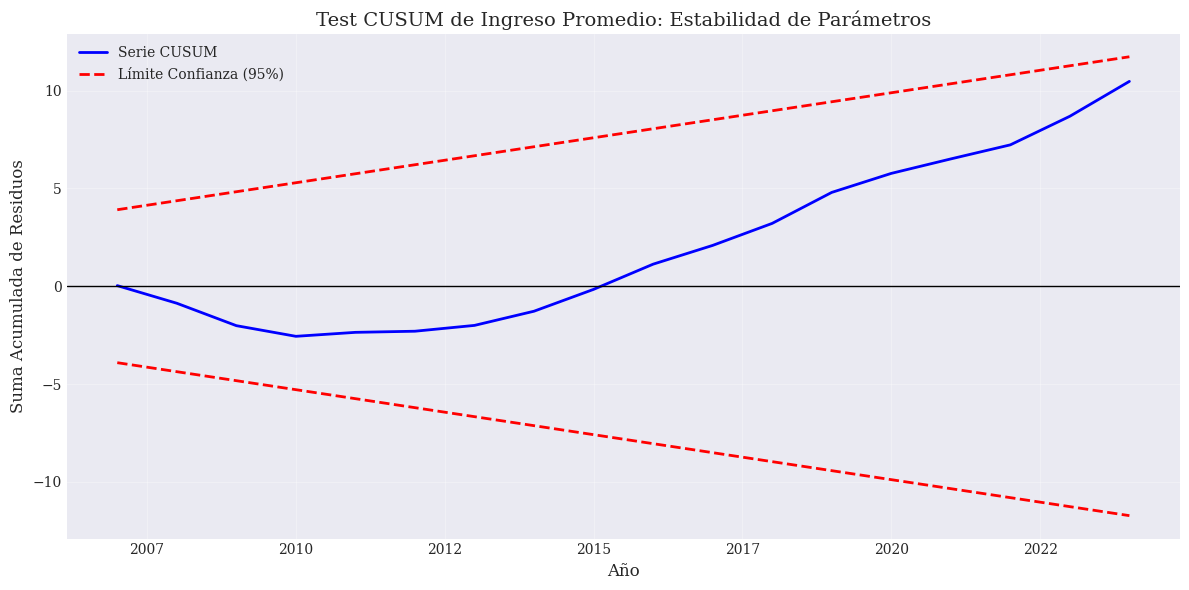

In [56]:
def graficar_cusum_ingreso(anio, cusum_valores, alpha=0.05):
    m = len(cusum_valores)

    # Valor crítico
    a = 0.948 if alpha == 0.05 else 1.143

    # Construcción de las bandas según Brown, Durbin & Evans
    # La fórmula estándar es: a * sqrt(T-k) + 2 * a * (t-k) / sqrt(T-k)
    # t_vals va de 0 a m-1
    t_vals = np.arange(m)
    sqrt_m = np.sqrt(m - 1)

    banda = a * sqrt_m + (2 * a * t_vals / sqrt_m)

    plt.figure(figsize=(12, 6))
    eje_x = anio[-m:]

    plt.plot(eje_x, cusum_valores, label='Serie CUSUM', color='blue', lw=2)
    plt.plot(eje_x, banda, label=f'Límite Confianza ({1-alpha:.0%})', color='red', ls='--')
    plt.plot(eje_x, -banda, color='red', ls='--')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):}'))

    plt.axhline(0, color='black', lw=1)
    plt.title('Test CUSUM de Ingreso Promedio: Estabilidad de Parámetros', fontsize=14)
    plt.xlabel('Año')
    plt.ylabel('Suma Acumulada de Residuos')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_cusum_ingreso(anio_input, serie_cusum_ingreso)

In [57]:
#Análisis CUSUM para la tasa de informalidad de trabajadores por cuenta propia
def modelo_cusum_tasa(anio, tasa):
    # 1. Preparación de datos
    X = np.column_stack([np.ones(len(anio)), anio])
    y = np.array(tasa)
    n, k = X.shape

    X_init = X[:k]
    y_init = y[:k]
    xtx_inv = np.linalg.inv(X_init.T @ X_init)
    beta_t = xtx_inv @ (X_init.T @ y_init)

    w = []
    for t in range(k, n):
        x_actual = X[t]
        prediccion = x_actual @ beta_t
        error = y[t] - prediccion

        # Factor de escala f_t
        f_t = 1 + x_actual @ xtx_inv @ x_actual.T
        w.append(error / np.sqrt(f_t))

        # Recursiva de la inversa (Sherman–Morrison)
        x_vec = x_actual.reshape(-1, 1)
        xtx_inv = xtx_inv - (xtx_inv @ x_vec @ x_vec.T @ xtx_inv) / (1 + x_vec.T @ xtx_inv @ x_vec)

        # Beta
        beta_t = xtx_inv @ (X[:t+1].T @ y[:t+1])

    w = np.array(w)

    # Estimación de sigma
    beta_full = np.linalg.inv(X.T @ X) @ (X.T @ y)
    residuos_full = y - X @ beta_full
    sigma = np.sqrt(np.sum(residuos_full**2) / (n - k))

    # CUSUM con normalización individual
    cusum_valores = np.cumsum(w / sigma)

    return cusum_valores


anio_input = df['anio'].values
tasa_input = df['tasa'].values

serie_cusum_tasa = modelo_cusum_tasa(anio_input, tasa_input)

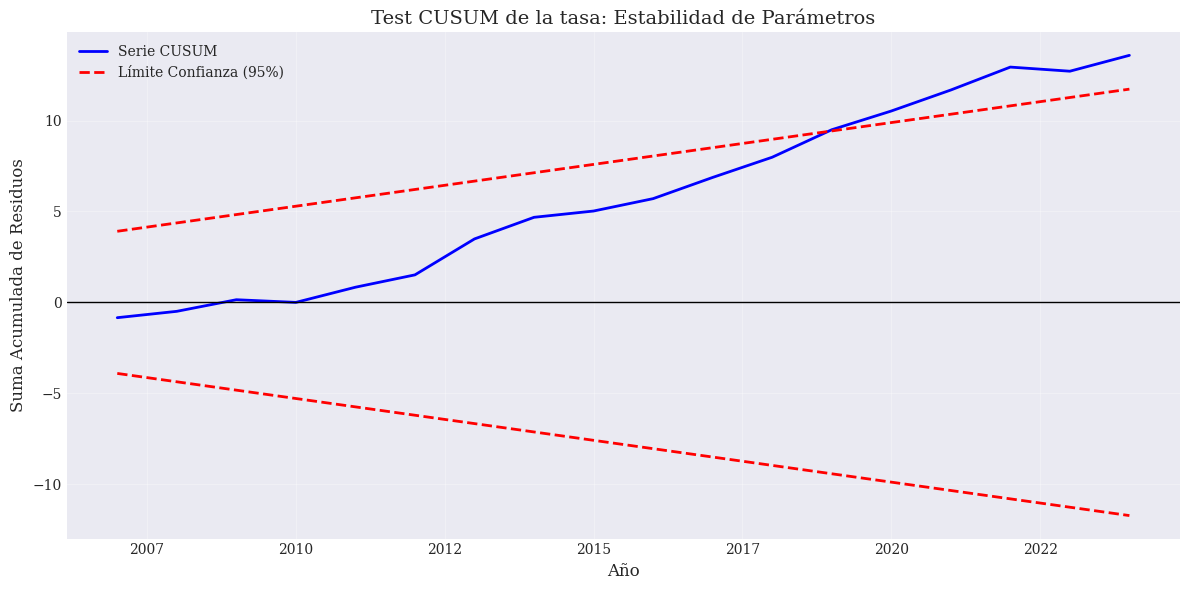

In [58]:
def graficar_cusum_tasa(anio, cusum_valores, alpha=0.05):
    m = len(cusum_valores)

    # Valor crítico
    a = 0.948 if alpha == 0.05 else 1.143

    # Construcción de las bandas según Brown, Durbin & Evans
    # La fórmula estándar es: a * sqrt(T-k) + 2 * a * (t-k) / sqrt(T-k)
    # t_vals va de 0 a m-1
    t_vals = np.arange(m)
    sqrt_m = np.sqrt(m - 1)

    banda = a * sqrt_m + (2 * a * t_vals / sqrt_m)

    plt.figure(figsize=(12, 6))
    eje_x = anio[-m:]

    plt.plot(eje_x, cusum_valores, label='Serie CUSUM', color='blue', lw=2)
    plt.plot(eje_x, banda, label=f'Límite Confianza ({1-alpha:.0%})', color='red', ls='--')
    plt.plot(eje_x, -banda, color='red', ls='--')
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):}'))

    plt.axhline(0, color='black', lw=1)
    plt.title('Test CUSUM de la tasa: Estabilidad de Parámetros', fontsize=14)
    plt.xlabel('Año')
    plt.ylabel('Suma Acumulada de Residuos')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_cusum_tasa(anio_input, serie_cusum_tasa)

# **2. Método de tiempo lineal exacto podado (PELT)**

In [59]:
!pip install ruptures
import ruptures as rpt

In [60]:
# Definir la penalización
n = 20
p = 1
penalty_bic = p * np.log(n)
print("Penalización BIC:", penalty_bic)

Penalización BIC: 2.995732273553991


In [61]:
# Puntos de cambio en la proporción de motocicletas por automóvil
def ruptures_change_point_detection ( df, proporcion, penalty= penalty_bic):
    algo = rpt.Pelt(model= "rbf").fit(df[proporcion].values)
    result = algo.predict(pen=penalty)
    return result
puntos_de_cambio = ruptures_change_point_detection(df, 'proporcion')
print(puntos_de_cambio)

[10, 20]


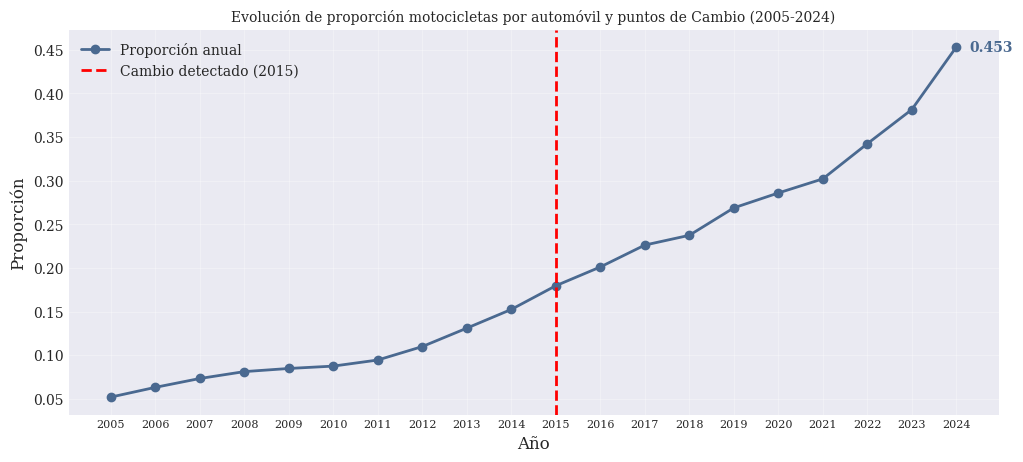

In [62]:
#Gráfica de puntos de cambio en la proporción de motocicletas por automóvil
# Lista de años
anios = list(range(2005, 2025))

# Punto detectado (índice 10)
puntos_indices = [10]
anios_cambio = [anios[i] for i in puntos_indices]

plt.figure(figsize=(12, 5))
plt.plot(anios, df['proporcion'].values, marker='o', linestyle='-', color=colores_azul['Azul6'], label='Proporción anual')
for año in anios_cambio:
    plt.axvline(x=año, color='red', linestyle='--', label=f'Cambio detectado ({año})')

plt.text(df['anio'].iloc[-1] + 0.3, df['proporcion'].iloc[-1],
         f"{df['proporcion'].iloc[-1]:,.3f}", color=colores_azul['Azul6'], fontweight='bold', va='center')

plt.title("Evolución de proporción motocicletas por automóvil y puntos de Cambio (2005-2024)")
plt.xlabel("Año")
plt.ylabel("Proporción")
plt.xticks(anios, rotation=0, fontsize=8)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


Punto de cambio detectado para la proporción de motocicletas por automóviles al cierre de 2015.

In [63]:
# Puntos de cambio en los ingresos laborales promedio
def ruptures_change_point_detection ( df, ingreso, penalty=penalty_bic):
    algo = rpt.Pelt(model= "rbf").fit(df[ingreso].values)
    result = algo.predict(pen=penalty)
    return result
puntos_de_cambio = ruptures_change_point_detection(df, 'ingreso')
print(puntos_de_cambio)

[20]


Sin puntos de cambio identificados para la variable de ingresos.

In [64]:
# Puntos de cambio en la tasa de informalidad de trabajadores por cuenta propia
def ruptures_change_point_detection ( df, tasa, penalty=penalty_bic):
    algo = rpt.Pelt(model= "rbf").fit(df[tasa].values)
    result = algo.predict(pen=penalty)
    return result
puntos_de_cambio = ruptures_change_point_detection(df, 'tasa')
print(puntos_de_cambio)

[20]


Sin puntos de cambio identificados para la variable de de tasa.

## Gráfica conjunta de CUSUM y PELT para la proporción moocicletas por automovil.

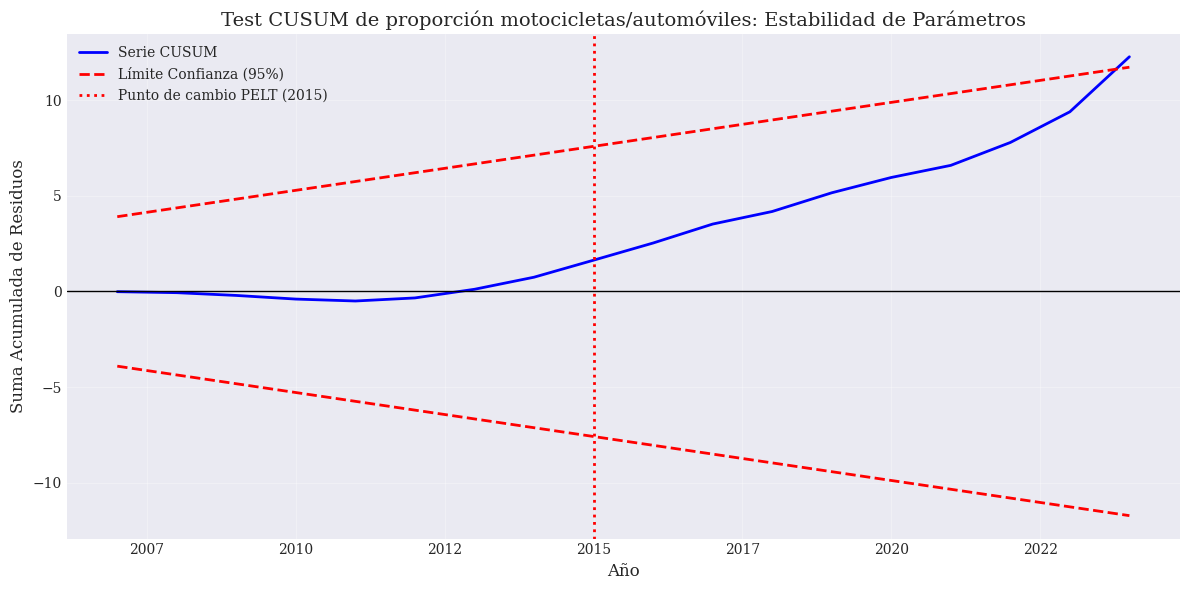

In [65]:
def graficar_cusum_propor(anio, cusum_valores, alpha=0.05):
    m = len(cusum_valores)

    # Valor crítico
    a = 0.948 if alpha == 0.05 else 1.143

    # Construcción de las bandas según Brown, Durbin & Evans
    # La fórmula estándar es: a * sqrt(T-k) + 2 * a * (t-k) / sqrt(T-k)
    # t_vals va de 0 a m-1
    t_vals = np.arange(m)
    sqrt_m = np.sqrt(m - 1)

    banda = a * sqrt_m + (2* a * t_vals / sqrt_m)

    plt.figure(figsize=(12, 6))
    eje_x = anio[-m:]

    plt.plot(eje_x, cusum_valores, label='Serie CUSUM', color='blue', lw=2)
    plt.plot(eje_x, banda, label=f'Límite Confianza ({1-alpha:.0%})', color='red', ls='--')
    plt.plot(eje_x, -banda, color='red', ls='--')

    plt.axvline(x=2015, color='red', linestyle=':', lw=2, label='Punto de cambio PELT (2015)')

    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):}'))

    plt.axhline(0, color='black', lw=1)
    plt.title('Test CUSUM de proporción motocicletas/automóviles: Estabilidad de Parámetros', fontsize=14)
    plt.xlabel('Año')
    plt.ylabel('Suma Acumulada de Residuos')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

graficar_cusum_propor(anio_input, serie_cusum_propor)

# **4. Análisis de elasticidades**


## **Análisis de la demanada (Ingreso-Proporción motos)**

In [66]:
# Definimos los periodos por su posición (índice 0, índice 10, índice 19)
# 0 = 2005, 10 = 2015, 19 = 2024
periodos = [
    ('Periodo 1 (Inicio a Quiebre)', 0, 10),
    ('Periodo 2 (Quiebre a Final)', 10, 19)
]

resultados_demanda = []

for nombre, inicio, fin in periodos:
    p1, p2 = df['proporcion'].iloc[inicio], df['proporcion'].iloc[fin]
    i1, i2 = df['ingreso'].iloc[inicio], df['ingreso'].iloc[fin]

    delta_p = (p2 - p1) / ((p1 + p2) / 2) # Cambio en proporción motos
    delta_i = (i2 - i1) / ((i1 + i2) / 2) # Cambio en Ingreso

    # Elasticidad Ingreso de la Demanda
    resultados_demanda.append({
        'Etapa': nombre,
        'Elasticidad_Motos_Ingreso': delta_p / delta_i if delta_i != 0 else 0
    })

df_demanda = pd.DataFrame(resultados_demanda)
print("--- Análisis de Demanda (Ingreso -> Proporción Motos) ---")
print(df_demanda)

--- Análisis de Demanda (Ingreso -> Proporción Motos) ---
                          Etapa  Elasticidad_Motos_Ingreso
0  Periodo 1 (Inicio a Quiebre)                  -9.569821
1   Periodo 2 (Quiebre a Final)                   9.640922


## **Análisis de impacto laboral (Proporción motos-Tasa)**

In [67]:
# Definimos los periodos por su posición (índice 0, índice 10, índice 19)
# 0 = 2005, 10 = 2015, 19 = 2024
periodos = [
    ('Periodo 1 (Inicio a Quiebre)', 0, 10),
    ('Periodo 2 (Quiebre a Final)', 10, 19)
]

resultados_laboral = []

for nombre, inicio, fin in periodos:
    p1, p2 = df['proporcion'].iloc[inicio], df['proporcion'].iloc[fin]
    t1, t2 = df['tasa'].iloc[inicio], df['tasa'].iloc[fin]

    delta_t = (t2 - t1) / ((t1 + t2) / 2) # Cambio en Informalidad
    delta_p = (p2 - p1) / ((p1 + p2) / 2) # Cambio proporción de motos

    # Elasticidad de la proporción motocicletas por automóvil respecto a la tasa de informalidad de trabajadores por cuenta propia dentro del empleo informal
    resultados_laboral.append({
        'Etapa': nombre,
        'Elasticidad_Informalidad_Motos': delta_t / delta_p if delta_p != 0 else 0
    })

df_laboral = pd.DataFrame(resultados_laboral)
print("\n--- Análisis de Impacto Laboral (Proporción motos -> Tasa) ---")
print(df_laboral)


--- Análisis de Impacto Laboral (Proporción motos -> Tasa) ---
                          Etapa  Elasticidad_Informalidad_Motos
0  Periodo 1 (Inicio a Quiebre)                       -0.094298
1   Periodo 2 (Quiebre a Final)                        0.105340
